In [79]:
import zipfile
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [80]:
zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 506


In [81]:
X = []
y = []

IMG_SIZE = 64

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):

            img_path = os.path.join(root, file)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize
                img = img / 255.0

                # Flatten
                img = img.flatten()

                X.append(img)

                # Assign labels
                if "yes" in root.lower():
                    y.append(1)   # Tumor
                elif "no" in root.lower():
                    y.append(0)   # No Tumor

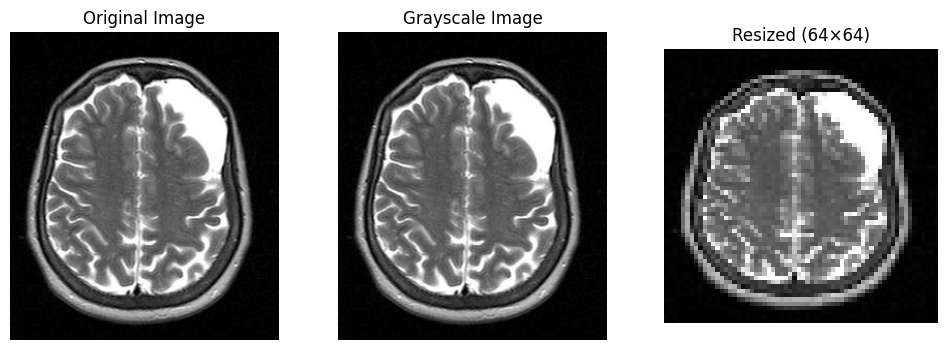

In [82]:
import matplotlib.pyplot as plt

# Example image path
sample_path = img_path  # or specify a particular image path

# Original image
original = cv2.imread(sample_path)

# Grayscale image
gray = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# Resized image
resized = cv2.resize(gray, (64, 64))

# Display images
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(resized, cmap='gray')
plt.title("Resized (64×64)")
plt.axis("off")

plt.show()

In [83]:
flattened = resized.flatten()

print("Shape before flattening:", resized.shape)
print("Shape after flattening:", flattened.shape)

Shape before flattening: (64, 64)
Shape after flattening: (4096,)


In [84]:
X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (506, 4096)
Labels Shape: (506,)


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 404
Testing Samples: 102


In [86]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [87]:
y_pred = rf.predict(X_test)

In [88]:
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Saving 1-s2.0-S2665917424000023-gr5.jpg to 1-s2.0-S2665917424000023-gr5 (2).jpg


In [89]:
# Load and preprocess the newly uploaded image
newly_uploaded_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if newly_uploaded_img is not None:
    # Resize to IMG_SIZE
    newly_uploaded_img = cv2.resize(newly_uploaded_img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    newly_uploaded_img = newly_uploaded_img / 255.0

    # Flatten
    newly_uploaded_img = newly_uploaded_img.flatten()

    # Reshape for single prediction (1 sample, IMG_SIZE*IMG_SIZE features)
    newly_uploaded_img = newly_uploaded_img.reshape(1, -1)

    # Make prediction
    prediction_uploaded = rf.predict(newly_uploaded_img)

    # Display the prediction
    if prediction_uploaded[0] == 1:
        print(f'Tumor Detected')
    else:
        print(f'No Tumor Detected')
else:
    print(f"Error: Could not load image. Please check the path and ensure it's a valid image file.")

Tumor Detected
